<a href="https://colab.research.google.com/github/tb267503/Covid-19_Pandemic/blob/master/CAT2_WHO_Covid_19_Jan22_2021_Tumsifu_Balolebwami_Blaise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CAT2_tb267503**

Done By: TUMSIFU BALOLEBWAMI **BLAISE**

CUU: MIT 2025 SEMESTER 2

In [85]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, jaccard_score

In [86]:
# Load dataset
url = "https://raw.githubusercontent.com/mkumakech/Covid-19_Pandemic/master/WHO_Covid_19_Jan22_2021.csv"
df = pd.read_csv(url, encoding='latin1')

# Display basic info
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 11 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Name                                               238 non-null    object 
 1   WHO Region                                         237 non-null    object 
 2   Cases _cumulative total                            238 non-null    int64  
 3   Cases _cumulative total per 1 million population   237 non-null    float64
 4   Cases _newly reported in last 7 days               238 non-null    int64  
 5   Cases _newly reported in last 24 hours             238 non-null    int64  
 6   Deaths _cumulative total                           238 non-null    int64  
 7   Deaths_ cumulative total per 1 million population  237 non-null    float64
 8   Deaths _newly reported in last 7 days              238 non-null    int64  
 9   Deaths _ne

In [87]:
# Remove leading/trailing spaces in column names
df.columns = df.columns.str.strip()

# Rename columns to simpler, more consistent names for numerical operations
column_renames = {
    'Cases _cumulative total': 'Cumulative_cases',
    'Cases _cumulative total per 1 million population': 'Cumulative_cases_per_million',
    'Cases _newly reported in last 7 days': 'New_cases_7_days',
    'Cases _newly reported in last 24 hours': 'New_cases',
    'Deaths _cumulative total': 'Cumulative_deaths',
    'Deaths_ cumulative total per 1 million population': 'Cumulative_deaths_per_million',
    'Deaths _newly reported in last 7 days': 'New_deaths_7_days',
    'Deaths _newly reported in last 24 hours': 'New_deaths'
}
df = df.rename(columns=column_renames)

# Remove duplicate rows
df = df.drop_duplicates()

# Remove rows with too many missing values
df = df.dropna(thresh=len(df.columns) * 0.7)

# Fill remaining missing values
df = df.ffill()

# Remove "Global" row (not useful for classification)
df = df[df['Name'] != 'Global']

# Remove special characters and spaces in categorical columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()
    df[col] = df[col].str.replace(r'[^a-zA-Z0-9 ]', '', regex=True)

# Convert numeric columns properly
numeric_cols = [
    'Cumulative_cases', 'New_cases',
    'Cumulative_deaths', 'New_deaths'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows still having NaN
df = df.dropna()

In [88]:
# Target variable
y = df['Transmission Classification']

# Drop unnecessary columns
X = df.drop([
    'Transmission Classification',
    'Name',
    'WHO Region'
], axis=1)

In [89]:
# Encode categorical variables
le = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col])

# Encode target
y = le.fit_transform(y)

In [90]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [92]:
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC()
}

results = {}

In [93]:
# =========================
# DECISION TREE CLASSIFIER
# =========================

dt = DecisionTreeClassifier(random_state=42)

# Train model
dt.fit(X_train, y_train)

# Predictions
y_pred_dt = dt.predict(X_test)

# Evaluation
print("=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Jaccard:", jaccard_score(y_test, y_pred_dt, average='weighted'))
print(classification_report(y_test, y_pred_dt))



=== Decision Tree ===
Accuracy: 0.5625
Jaccard: 0.4292792792792792
              precision    recall  f1-score   support

           0       0.29      0.40      0.33        10
           1       0.73      0.63      0.68        30
           2       0.75      0.75      0.75         4
           4       0.00      0.00      0.00         0
           5       0.50      0.25      0.33         4

    accuracy                           0.56        48
   macro avg       0.45      0.41      0.42        48
weighted avg       0.62      0.56      0.58        48



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Figure size 2000x1000 with 0 Axes>

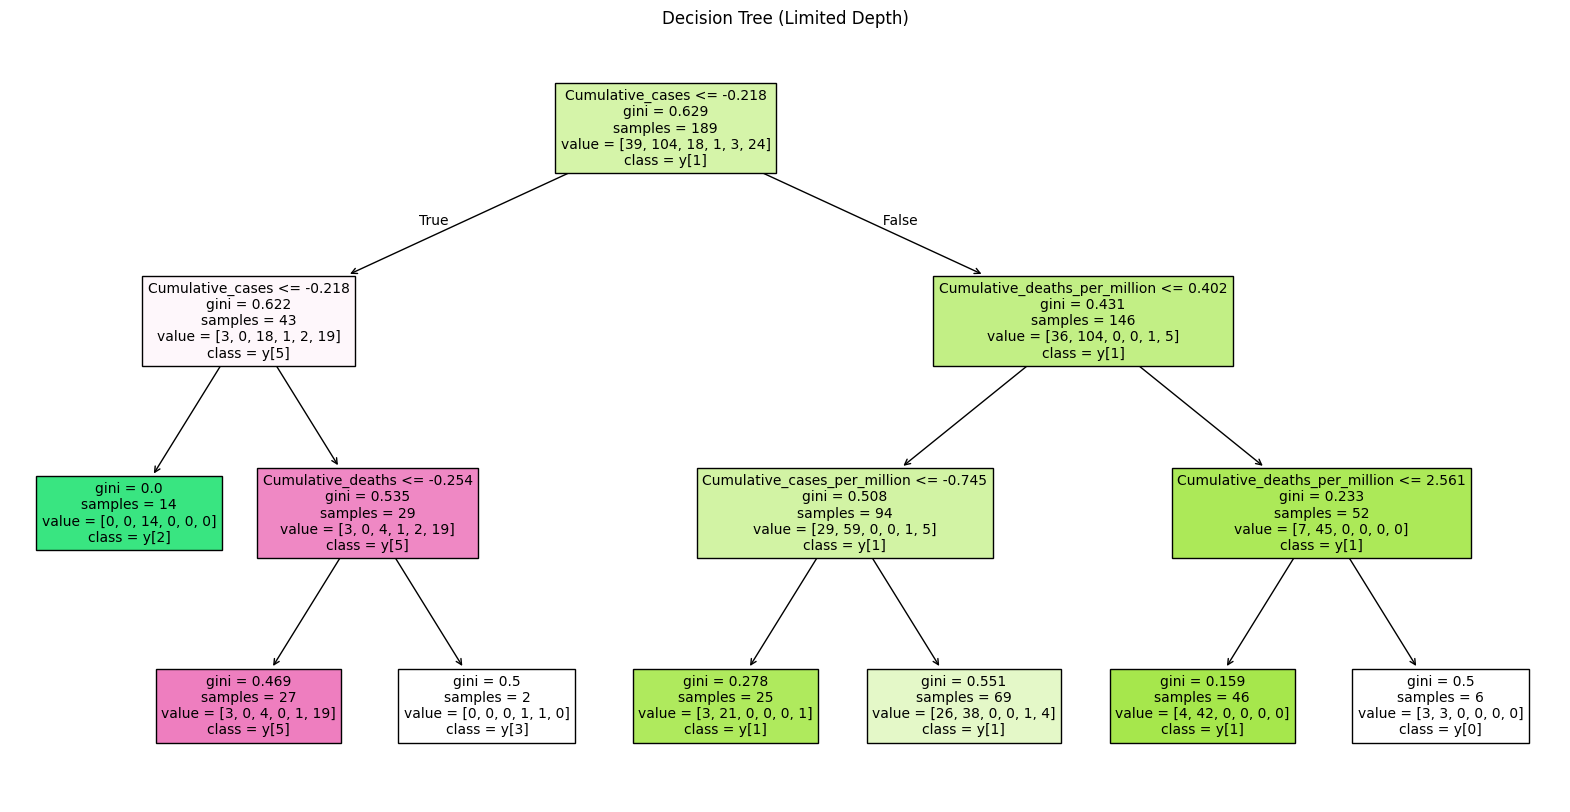

In [94]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

DecisionTreeClassifier(max_depth=10)
plt.figure(figsize=(20,10))
# Limit tree depth
dt = DecisionTreeClassifier(max_depth=3, random_state=42)

dt.fit(X_train, y_train)

# Plot
plt.figure(figsize=(20,10))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=True,
    filled=True,
    fontsize=10
)

plt.title("Decision Tree (Limited Depth)")
plt.show()


In [95]:
# =========================
# RANDOM FOREST CLASSIFIER
# =========================

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

# Train the model
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluation metrics
print("=== Random Forest Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Jaccard:", jaccard_score(y_test, y_pred_rf, average='weighted'))
print(classification_report(y_test, y_pred_rf))

=== Random Forest Results ===
Accuracy: 0.5833333333333334
Jaccard: 0.42369015356820233
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.69      0.83      0.76        30
           2       0.67      0.50      0.57         4
           5       0.17      0.25      0.20         4

    accuracy                           0.58        48
   macro avg       0.38      0.40      0.38        48
weighted avg       0.50      0.58      0.54        48



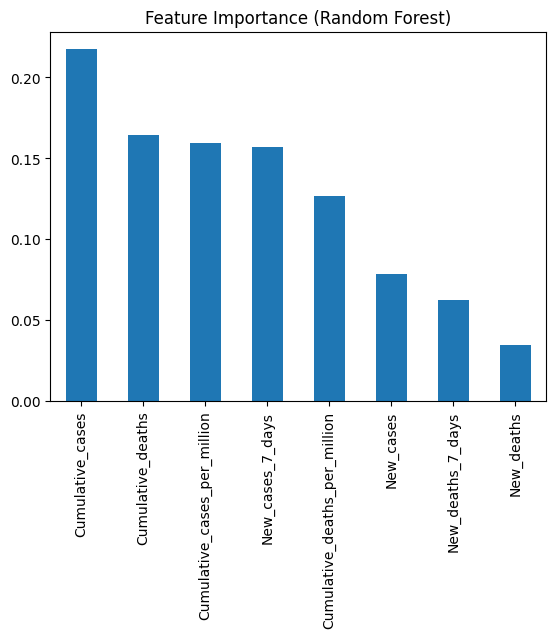

In [96]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind='bar')

plt.title("Feature Importance (Random Forest)")
plt.show()

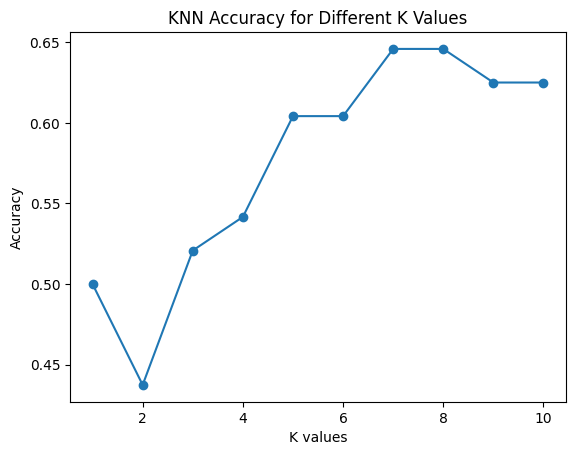

In [97]:
# =========================
# KNN - Accuracy vs K
# =========================

k_values = range(1, 11)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    # Train model
    knn.fit(X_train, y_train)

    # Evaluate
    score = knn.score(X_test, y_test)
    accuracies.append(score)

# Plot the results
plt.figure()
plt.plot(k_values, accuracies, marker='o')

plt.title("KNN Accuracy for Different K Values")
plt.xlabel("K values")
plt.ylabel("Accuracy")

plt.show()

=== SVM ===
Accuracy: 0.625
Jaccard: 0.390625
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.62      1.00      0.77        30
           2       0.00      0.00      0.00         4
           5       0.00      0.00      0.00         4

    accuracy                           0.62        48
   macro avg       0.16      0.25      0.19        48
weighted avg       0.39      0.62      0.48        48



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


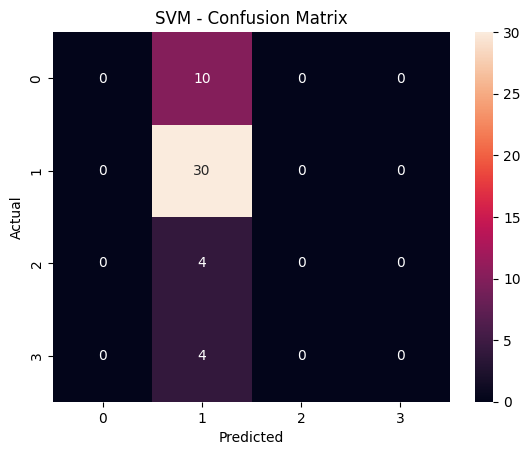

In [98]:
# =========================
# SVM CLASSIFIER
# =========================

svm = SVC(kernel='rbf')

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("=== SVM ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Jaccard:", jaccard_score(y_test, y_pred_svm, average='weighted'))
print(classification_report(y_test, y_pred_svm))

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure()
sns.heatmap(cm_svm, annot=True, fmt='d')
plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [99]:
# =========================
# MODEL COMPARISON
# =========================

results = {
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "SVM": accuracy_score(y_test, y_pred_svm),
}

for model, score in results.items():
    print(f"{model}: {score:.4f}")

Decision Tree: 0.5625
Random Forest: 0.5833
KNN: 0.6042
SVM: 0.6250


In [100]:
# =========================
# KNN BY WHO REGION
# =========================

regions = df['WHO Region'].unique()

for region in regions:

    print("\n==============================")
    print(f"Region: {region}")
    print("==============================")

    # Filter dataset by region
    df_region = df[df['WHO Region'] == region]

    # Skip small datasets
    if len(df_region) < 20:
        print("Not enough data")
        continue

    # Define X and y
    y = df_region['Transmission Classification']
    X = df_region.drop([
        'Transmission Classification',
        'Name'
    ], axis=1)

    # Encode categorical variables
    le = LabelEncoder()

    for col in X.select_dtypes(include='object').columns:
        X[col] = le.fit_transform(X[col])

    y = le.fit_transform(y)

    # Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Train/Test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )

    # KNN model
    knn = KNeighborsClassifier(n_neighbors=5)

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    # Results
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Jaccard:", jaccard_score(y_test, y_pred, average='weighted'))
    print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Region: Africa
Accuracy: 0.7
Jaccard: 0.48999999999999994
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.70      1.00      0.82         7
           3       0.00      0.00      0.00         1

    accuracy                           0.70        10
   macro avg       0.23      0.33      0.27        10
weighted avg       0.49      0.70      0.58        10


Region: Americas
Accuracy: 0.5
Jaccard: 0.2916666666666667
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.55      0.86      0.67         7
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         2

    accuracy                           0.50        12
   macro avg       0.14      0.21      0.17        12
weighted avg       0.32      0.50      0.39        12


Region: Eastern Mediterranean
Accuracy: 0.8
Jaccard: 0.64
      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [101]:
results = {}

for region in df['WHO Region'].unique():
    df_region = df[df['WHO Region'] == region]

    if len(df_region) < 20:
        continue

    y = df_region['Transmission Classification']
    X = df_region.drop(['Transmission Classification','Name'], axis=1)

    le = LabelEncoder()
    for col in X.select_dtypes(include='object').columns:
        X[col] = le.fit_transform(X[col])
    y = le.fit_transform(y)

    X_scaled = StandardScaler().fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)

    acc = knn.score(X_test, y_test)
    results[region] = acc

print("\n=== Accuracy by Region ===")
for r, v in results.items():
    print(f"{r}: {v:.4f}")


=== Accuracy by Region ===
Africa: 1.0000
Americas: 0.6667
Eastern Mediterranean: 0.4000
Europe: 0.3846
Western Pacific: 0.5714


In [102]:
results = {}

for region in df['WHO Region'].unique():
    df_region = df[df['WHO Region'] == region]

    if len(df_region) < 20:
        continue

    y = df_region['Transmission Classification']
    X = df_region.drop(['Transmission Classification','Name'], axis=1)

    le = LabelEncoder()
    for col in X.select_dtypes(include='object').columns:
        X[col] = le.fit_transform(X[col])
    y = le.fit_transform(y)

    X_scaled = StandardScaler().fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42 # Added random_state for reproducibility
    )

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)

    acc = knn.score(X_test, y_test)
    results[region] = acc

print("\n=== Accuracy by Region ===")
for r, v in results.items():
    print(f"{r}: {v:.4f}")


=== Accuracy by Region ===
Africa: 0.7000
Americas: 0.5000
Eastern Mediterranean: 0.8000
Europe: 0.4615
Western Pacific: 0.5714


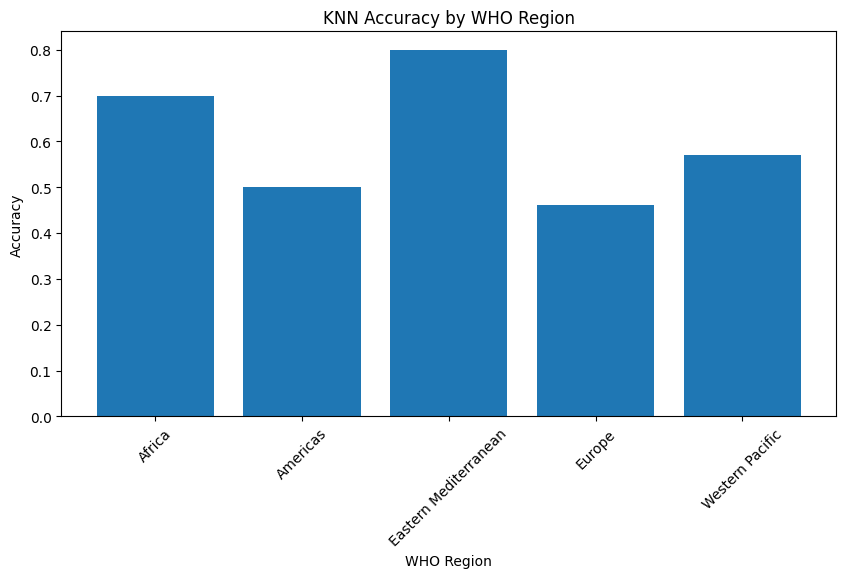

In [103]:
import matplotlib.pyplot as plt

# results = dict(region -> accuracy) from previous code
regions = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(10,5))
plt.bar(regions, accuracies)

plt.title("KNN Accuracy by WHO Region")
plt.xlabel("WHO Region")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)

plt.show()

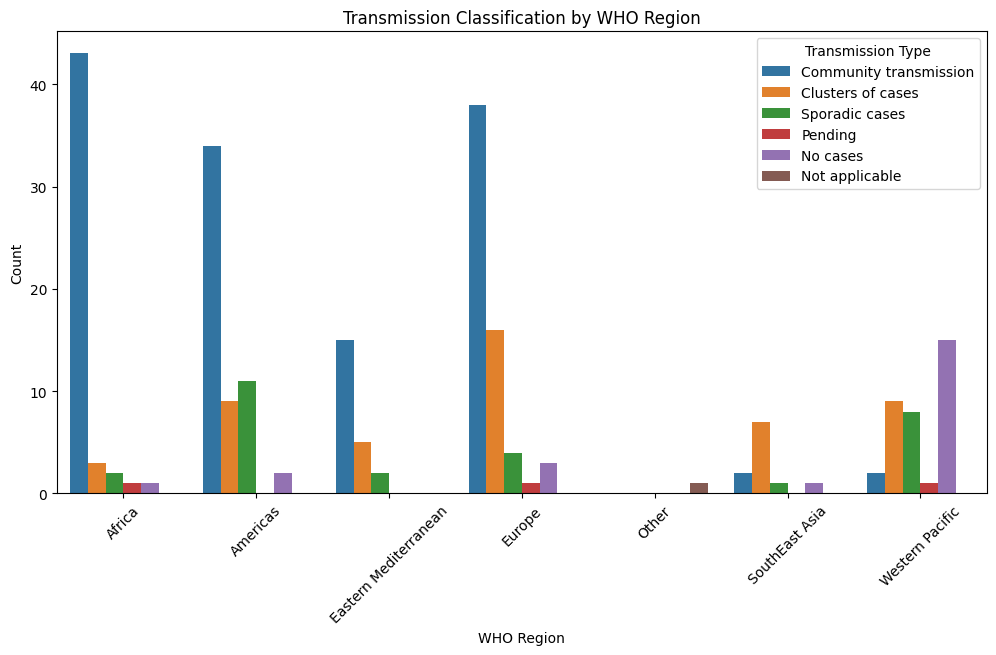

In [104]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.countplot(data=df, x='WHO Region', hue='Transmission Classification')

plt.title("Transmission Classification by WHO Region")
plt.xlabel("WHO Region")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.legend(title="Transmission Type")

plt.show()

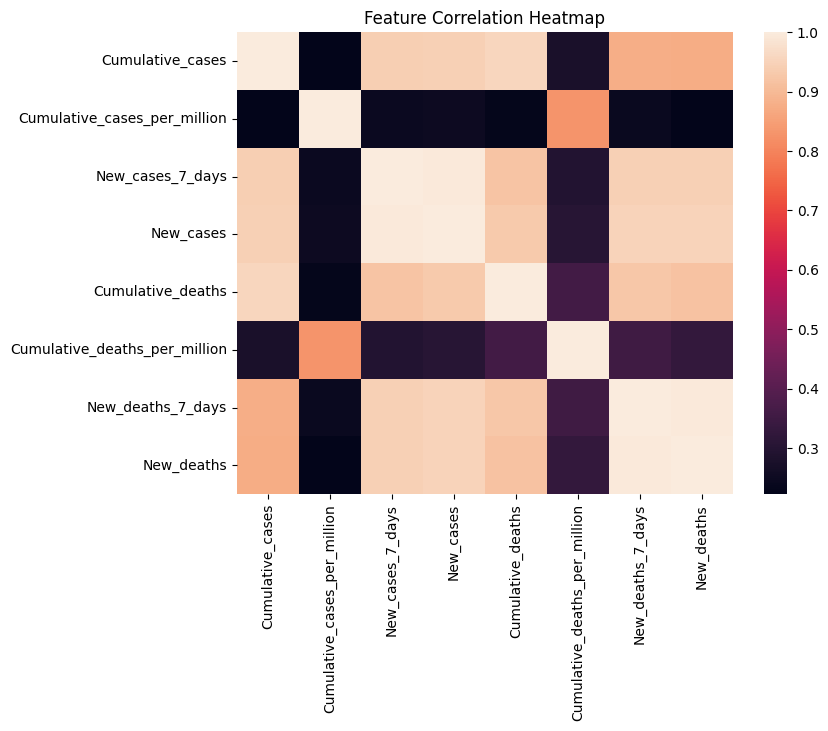

In [105]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=False)

plt.title("Feature Correlation Heatmap")
plt.show()